### Step 1: Read the file

In [1]:
import pandas as pd
df=pd.read_csv("bigmart.csv")

df.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [2]:
df.columns

Index(['Item_Identifier', 'Item_Weight', 'Item_Fat_Content', 'Item_Visibility',
       'Item_Type', 'Item_MRP', 'Outlet_Identifier',
       'Outlet_Establishment_Year', 'Outlet_Size', 'Outlet_Location_Type',
       'Outlet_Type', 'Item_Outlet_Sales'],
      dtype='str')

### Step 2: Impute missing values

In [3]:
df.isnull().sum()

Item_Identifier                 0
Item_Weight                  1463
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  2410
Outlet_Location_Type            0
Outlet_Type                     0
Item_Outlet_Sales               0
dtype: int64

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   str    
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   str    
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   str    
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   str    
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   str    
 9   Outlet_Location_Type       8523 non-null   str    
 10  Outlet_Type                8523 non-null   str    
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), str(7)
memory usage: 799.2 KB


In [5]:
df.Outlet_Size.value_counts()


Outlet_Size
Medium    2793
Small     2388
High       932
Name: count, dtype: int64

In [6]:
mean=df['Item_Weight'].mean()
df['Item_Weight']=df['Item_Weight'].fillna(mean)
print(mean)

12.857645184135977


In [7]:
mode = df['Outlet_Size'].mode()[0]
print(mode)
df['Outlet_Size'].fillna(mode, inplace =True)

Medium


C:\Users\hp\AppData\Local\Temp\ipykernel_6208\3910844968.py:3: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['Outlet_Size'].fillna(mode, inplace =True)


0       Medium
1       Medium
2       Medium
3       Medium
4         High
         ...  
8518      High
8519    Medium
8520     Small
8521    Medium
8522     Small
Name: Outlet_Size, Length: 8523, dtype: str

### Step 3: Deal with categorical variables and drop the id columns

In [8]:
df.drop(['Item_Identifier', 'Outlet_Identifier'], axis=1, inplace=True )

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Weight                8523 non-null   float64
 1   Item_Fat_Content           8523 non-null   str    
 2   Item_Visibility            8523 non-null   float64
 3   Item_Type                  8523 non-null   str    
 4   Item_MRP                   8523 non-null   float64
 5   Outlet_Establishment_Year  8523 non-null   int64  
 6   Outlet_Size                6113 non-null   str    
 7   Outlet_Location_Type       8523 non-null   str    
 8   Outlet_Type                8523 non-null   str    
 9   Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), str(5)
memory usage: 666.0 KB


In [10]:
obj_col_list=df.select_dtypes(include='str').columns.tolist()
print(obj_col_list)

['Item_Fat_Content', 'Item_Type', 'Outlet_Size', 'Outlet_Location_Type', 'Outlet_Type']


In [11]:
for i in obj_col_list:
   
    print(df[i].value_counts())
    print('-'*50)

Item_Fat_Content
Low Fat    5089
Regular    2889
LF          316
reg         117
low fat     112
Name: count, dtype: int64
--------------------------------------------------
Item_Type
Fruits and Vegetables    1232
Snack Foods              1200
Household                 910
Frozen Foods              856
Dairy                     682
Canned                    649
Baking Goods              648
Health and Hygiene        520
Soft Drinks               445
Meat                      425
Breads                    251
Hard Drinks               214
Others                    169
Starchy Foods             148
Breakfast                 110
Seafood                    64
Name: count, dtype: int64
--------------------------------------------------
Outlet_Size
Medium    2793
Small     2388
High       932
Name: count, dtype: int64
--------------------------------------------------
Outlet_Location_Type
Tier 3    3350
Tier 2    2785
Tier 1    2388
Name: count, dtype: int64
---------------------------------

In [12]:
df.loc[df['Item_Fat_Content']=='Low Fat','Item_Fat_Content']='law fat'
df.loc[df['Item_Fat_Content']=='LF','Item_Fat_Content']='law fat'
df.loc[df['Item_Fat_Content']=='reg','Item_Fat_Content']='Regular'

In [13]:
for i in obj_col_list:
    print(df[i].value_counts())
    print("-"*50)

Item_Fat_Content
law fat    5405
Regular    3006
low fat     112
Name: count, dtype: int64
--------------------------------------------------
Item_Type
Fruits and Vegetables    1232
Snack Foods              1200
Household                 910
Frozen Foods              856
Dairy                     682
Canned                    649
Baking Goods              648
Health and Hygiene        520
Soft Drinks               445
Meat                      425
Breads                    251
Hard Drinks               214
Others                    169
Starchy Foods             148
Breakfast                 110
Seafood                    64
Name: count, dtype: int64
--------------------------------------------------
Outlet_Size
Medium    2793
Small     2388
High       932
Name: count, dtype: int64
--------------------------------------------------
Outlet_Location_Type
Tier 3    3350
Tier 2    2785
Tier 1    2388
Name: count, dtype: int64
--------------------------------------------------
Outlet_Type
Su

In [14]:
df = pd.get_dummies(df,drop_first=True)

In [15]:
df.head()

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales,Item_Fat_Content_law fat,Item_Fat_Content_low fat,Item_Type_Breads,Item_Type_Breakfast,Item_Type_Canned,...,Item_Type_Snack Foods,Item_Type_Soft Drinks,Item_Type_Starchy Foods,Outlet_Size_Medium,Outlet_Size_Small,Outlet_Location_Type_Tier 2,Outlet_Location_Type_Tier 3,Outlet_Type_Supermarket Type1,Outlet_Type_Supermarket Type2,Outlet_Type_Supermarket Type3
0,9.30,0.016047,249.8092,1999,3735.1380,True,False,False,False,False,...,False,False,False,True,False,False,False,True,False,False
1,5.92,0.019278,48.2692,2009,443.4228,False,False,False,False,False,...,False,True,False,True,False,False,True,False,True,False
2,17.50,0.016760,141.6180,1999,2097.2700,True,False,False,False,False,...,False,False,False,True,False,False,False,True,False,False
3,19.20,0.000000,182.0950,1998,732.3800,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
4,8.93,0.000000,53.8614,1987,994.7052,True,False,False,False,False,...,False,False,False,False,False,False,True,True,False,False


### Step 4: Create a train and a test set

In [16]:
from sklearn.model_selection import train_test_split
train,test=train_test_split(df,test_size=0.3)

x_train=train.drop('Item_Outlet_Sales', axis=1)
y_train = train['Item_Outlet_Sales']

x_test=test.drop('Item_Outlet_Sales', axis = 1)
y_test=test['Item_Outlet_Sales']

### Step 5: Preprocessing – Scaling the features

In [17]:
from sklearn.preprocessing import MinMaxScaler
import pandas as pd

scaler=MinMaxScaler()

x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

x_train = pd.DataFrame(
    x_train_scaled,
    columns=x_train.columns,
    index=x_train.index
)

x_test=pd.DataFrame(
    x_test_scaled,
    columns=x_test.columns,
    index=x_test.index
)

### Step 6: Let’s examine the error rate for different k values.

In [18]:
from sklearn import neighbors
from sklearn.metrics import mean_squared_error

from math import sqrt
import matplotlib.pyplot as plt

In [19]:
rmse_val=[]
for K in range(2,20):
    model= neighbors.KNeighborsRegressor(n_neighbors = K)
    model.fit(x_train,y_train)
    pred=model.predict(x_test) 
    error = sqrt(mean_squared_error(y_test,pred)) 
    rmse_val.append(error) 
    print('RMSE value for k= ' , K , 'is:', error)

RMSE value for k=  2 is: 1363.468689246268
RMSE value for k=  3 is: 1287.3021608486856
RMSE value for k=  4 is: 1245.9068267308835
RMSE value for k=  5 is: 1226.0886577328436
RMSE value for k=  6 is: 1220.5810409261812
RMSE value for k=  7 is: 1205.2538983001498
RMSE value for k=  8 is: 1206.5074946402588
RMSE value for k=  9 is: 1207.3879553223042
RMSE value for k=  10 is: 1204.0205056355503
RMSE value for k=  11 is: 1206.8723349857296
RMSE value for k=  12 is: 1209.438453016673
RMSE value for k=  13 is: 1213.6894391692433
RMSE value for k=  14 is: 1215.8052856524557
RMSE value for k=  15 is: 1219.7435877518196
RMSE value for k=  16 is: 1226.189064978786
RMSE value for k=  17 is: 1235.248417658671
RMSE value for k=  18 is: 1242.376333080246
RMSE value for k=  19 is: 1246.8085537596667


In [20]:
df.isnull().sum()

Item_Weight                        0
Item_Visibility                    0
Item_MRP                           0
Outlet_Establishment_Year          0
Item_Outlet_Sales                  0
Item_Fat_Content_law fat           0
Item_Fat_Content_low fat           0
Item_Type_Breads                   0
Item_Type_Breakfast                0
Item_Type_Canned                   0
Item_Type_Dairy                    0
Item_Type_Frozen Foods             0
Item_Type_Fruits and Vegetables    0
Item_Type_Hard Drinks              0
Item_Type_Health and Hygiene       0
Item_Type_Household                0
Item_Type_Meat                     0
Item_Type_Others                   0
Item_Type_Seafood                  0
Item_Type_Snack Foods              0
Item_Type_Soft Drinks              0
Item_Type_Starchy Foods            0
Outlet_Size_Medium                 0
Outlet_Size_Small                  0
Outlet_Location_Type_Tier 2        0
Outlet_Location_Type_Tier 3        0
Outlet_Type_Supermarket Type1      0
O

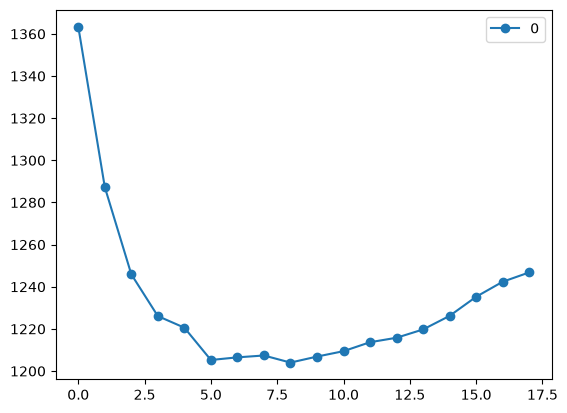

In [21]:
curve = pd.DataFrame(rmse_val)

curve.plot(marker='o')

plt.show()

###  Step 7 Create final KNN model with best K

In [23]:
from sklearn.neighbors import KNeighborsRegressor

knn = KNeighborsRegressor(n_neighbors=7)


knn.fit(x_train, y_train)


y_pred = knn.predict(x_test)

In [24]:
from sklearn.metrics import mean_squared_error
from math import sqrt

rmse = sqrt(mean_squared_error(y_test, y_pred))

print("RMSE:", rmse)

RMSE: 1205.2538983001498


In [25]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)

print("R2 Score:", r2)

R2 Score: 0.49033858448546574


In [26]:
result = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred
})

print(result.head(10))

         Actual    Predicted
7988  1587.9330  1803.271743
7516  4504.1370  2562.949543
671   1534.0032  1884.499343
2253  1935.4806  4539.804857
3573  1518.0240  2257.442457
2909   905.4880  1618.464686
8304  1917.5040  2431.311371
849    565.2642   425.160857
6808   980.0576  1064.899543
5140  1757.7120  1392.092686


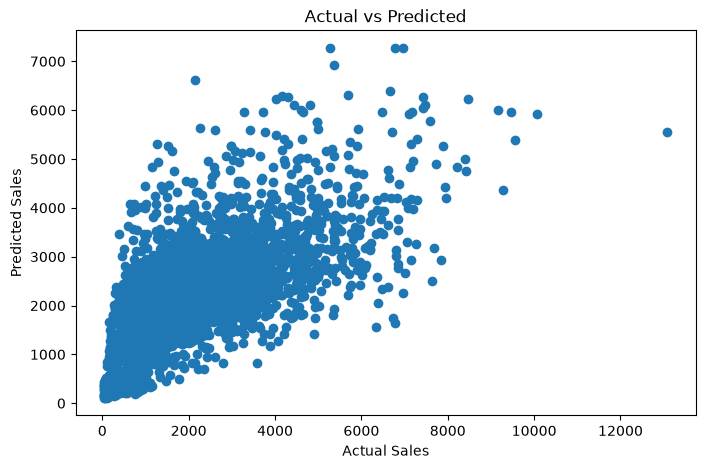

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted")
plt.show()

### Step 9: Implementing GridsearchCV

In [28]:
from sklearn.model_selection import GridSearchCV
params = {'n_neighbors':[2,3,4,5,6,7,8,9]}

knn = neighbors.KNeighborsRegressor()

model = GridSearchCV(knn, params, cv=5)
model.fit(x_train,y_train)
model.best_params_

{'n_neighbors': 8}

### Step 7 Create final KNN model with best K

In [30]:
from sklearn.neighbors import KNeighborsRegressor

knn8 = KNeighborsRegressor(n_neighbors=8)

knn8.fit(x_train, y_train)

y_pred8 = knn8.predict(x_test)

In [31]:
from sklearn.metrics import mean_squared_error
from math import sqrt

rmse = sqrt(mean_squared_error(y_test, y_pred8))

print("RMSE:", rmse)

RMSE: 1206.5074946402588


In [32]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred8)

print("R2 Score:", r2)

R2 Score: 0.4892778254965353
